In [ ]:
import requests
from bs4 import BeautifulSoup
import csv
def get_field_multi(soup, labels):

    for label in labels:
        strong_tag = soup.find("strong", string=lambda s: s and label in s)
        if strong_tag:
            text = strong_tag.parent.get_text(strip=True)
            if ":" in text:
                return text.split(":", 1)[1].strip()
            else:
                return text.replace(label, "").strip()
    return ""

all_data = []

for page in range(1, 20):
    if page == 1:
        url = "https://tracuuduoclieu.vn/tra-cuu-duoc-lieu"
    else:
        url = f"https://tracuuduoclieu.vn/tra-cuu-duoc-lieu/page/{page}"

    res = requests.get(url)
    soup = BeautifulSoup(res.text, "html.parser")

    items = soup.find_all("div", class_="dl")

    for item in items:
        a_tag = item.find("h2").find("a") if item.find("h2") else None
        if not a_tag:
            continue

        name = a_tag.text.strip()
        detail_url = a_tag["href"]

        detail_res = requests.get(detail_url)
        detail_soup = BeautifulSoup(detail_res.text, "html.parser")

        science_name = get_field_multi(detail_soup, ["Tên khoa học"])


        all_data.append([name, science_name])
        print("Đã crawl xong", name)


with open("cay_duoc_lieu.csv", "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)
    writer.writerow(["Name", "Science_name"])
    writer.writerows(all_data)

print("Đã lưu thành công: cay_duoc_lieu.csv")


Đã crawl xong Cao cẳng bắc bộ
Đã crawl xong Cao cẳng lá mác
Đã crawl xong Cao cẳng trung gian
Đã crawl xong Sài hồ
Đã crawl xong Dây lửa ít gân
Đã crawl xong Trám hồng
Đã crawl xong Thiên danh tinh
Đã crawl xong Nho biển
Đã crawl xong Su hào
Đã crawl xong Hương thảo
Đã crawl xong Chanh trường
Đã crawl xong Sương sáo
Đã crawl xong Bản xé thơm
Đã crawl xong Bại tượng hoa trắng
Đã crawl xong A kê
Đã crawl xong Áo cộc
Đã crawl xong Anh đào
Đã crawl xong Anh thảo
Đã crawl xong Sâm tố nữ
Đã crawl xong Giảo cổ lam
Đã crawl xong Thảo quả
Đã crawl xong Sâm cau
Đã crawl xong Cà gai leo
Đã crawl xong Xạ can
Đã crawl xong Tỏi
Đã crawl xong Địa Liền
Đã crawl xong Sữa ong chúa
Đã crawl xong Lược vàng
Đã crawl xong Dừa nước (Dừa lá)
Đã crawl xong Bạch nhất hồng
Đã crawl xong Mùng thơm
Đã crawl xong Muồng nước
Đã crawl xong Muồng trinh nữ
Đã crawl xong Muỗm
Đã crawl xong Nàng nàng lá to
Đã crawl xong Nắp ấm hoa đôi
Đã crawl xong Ngà voi
Đã crawl xong Ngải đắng
Đã crawl xong Nghể chàm
Đã crawl xong Ngh

Số lượng mẫu: 456


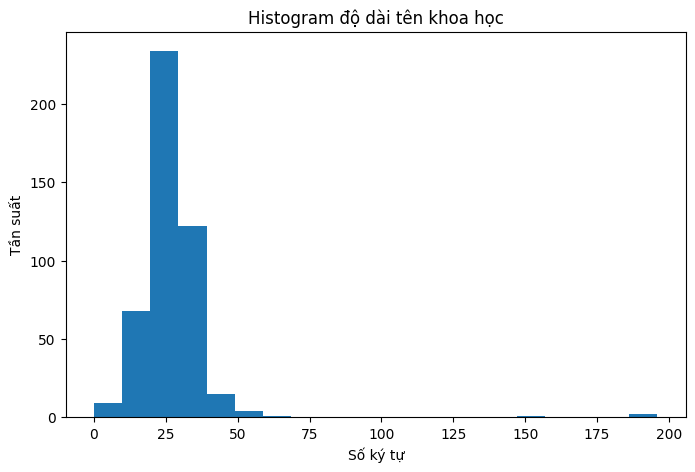

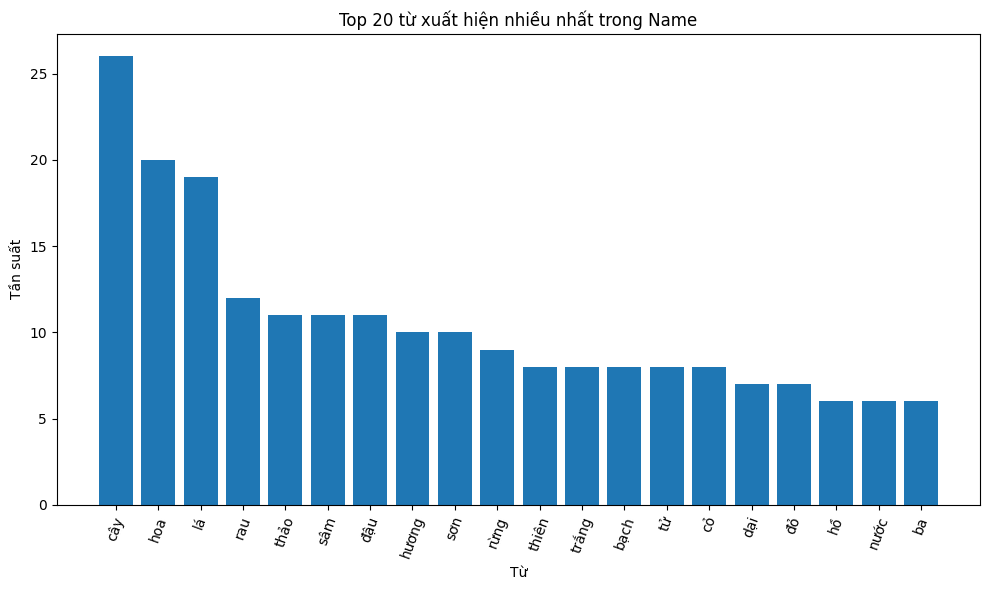


5 dòng đầu:
                  Name                            Science_name  science_len
0      Cao cẳng bắc bộ            Ophiopogon tonki-nensisRodr.           28
1      Cao cẳng lá mác  Ophiopogon dracaenoides(Baker) Hook.f.           38
2  Cao cẳng trung gian            Ophiopogon intermedius D.Don           28
3               Sài hồ                   Bupleurum chinenseDC.           21
4       Dây lửa ít gân                Rourea oligophlebiaMerr.           24


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

df = pd.read_csv("cay_duoc_lieu.csv")
df = df.fillna("")

print("Số lượng mẫu:", len(df))


df["science_len"] = df["Science_name"].apply(lambda x: len(str(x)))

plt.figure(figsize=(8,5))
plt.hist(df["science_len"], bins=20)
plt.title("Histogram độ dài tên khoa học")
plt.xlabel("Số ký tự")
plt.ylabel("Tần suất")
plt.show()

def visualize_top_vi_words(df, column="Name", top_k=20):
    def tokenize(text):
        text = text.lower()
        pattern = r"[A-Za-zÀ-Ỹà-ỹĐđ]+"
        return re.findall(pattern, str(text))

    all_words = []

    for item in df[column]:
        all_words.extend(tokenize(item))

    freq = Counter(all_words).most_common(top_k)

    labels = [w for w, _ in freq]
    values = [c for _, c in freq]

    plt.figure(figsize=(10, 6))
    plt.bar(labels, values)
    plt.xticks(rotation=70)
    plt.title(f"Top {top_k} từ xuất hiện nhiều nhất trong {column}")
    plt.xlabel("Từ")
    plt.ylabel("Tần suất")
    plt.tight_layout()
    plt.show()

    print("\n5 dòng đầu:")
    print(df.head())

visualize_top_vi_words(df, column="Name", top_k=20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Name          456 non-null    object
 1   Science_name  456 non-null    object
 2   science_len   456 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 10.8+ KB


In [ ]:
df.head()

,Name,Science_name,science_len
0,Cao cẳng bắc bộ,Ophiopogon tonki-nensisRodr.,28
1,Cao cẳng lá mác,Ophiopogon dracaenoides(Baker) Hook.f.,38
2,Cao cẳng trung gian,Ophiopogon intermedius D.Don,28
3,Sài hồ,Bupleurum chinenseDC.,21
4,Dây lửa ít gân,Rourea oligophlebiaMerr.,24


In [ ]:
print("Tổng số mẫu:", len(df))
print("Số tên khoa học khác nhau:", df["Science_name"].nunique())
print("Số name khác nhau:", df["Name"].nunique())

print("Số Science_name bị thiếu:", df["Science_name"].isna().sum())

Tổng số mẫu: 456
Số tên khoa học khác nhau: 442
Số name khác nhau: 455
Số Science_name bị thiếu: 0


In [ ]:
import pandas as pd

INPUT_FILE = "cay_duoc_lieu.csv"

OUTPUT_FILE = "cay_duoc_lieu_unique_science_name.csv"

try:
    df = pd.read_csv(INPUT_FILE)

    print(f"Số lượng hàng ban đầu (trước khi xóa): {len(df)}")

    df_unique = df.drop_duplicates(subset=['Science_name'], keep='first')

    print(f"Số lượng hàng sau khi xóa trùng lặp (theo Science_name): {len(df_unique)}")

    df_unique.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")

    print(f"\n Đã hoàn tất và lưu kết quả vào file: {OUTPUT_FILE}")
    print("DataFrame mới chỉ chứa một bản ghi duy nhất cho mỗi Science_name.")

except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file '{INPUT_FILE}'. Vui lòng đảm bảo file đã được tải lên.")
except Exception as e:
    print(f"Đã xảy ra lỗi trong quá trình xử lý: {e}")

Số lượng hàng ban đầu (trước khi xóa): 456
Số lượng hàng sau khi xóa trùng lặp (theo Science_name): 442

 Đã hoàn tất và lưu kết quả vào file: cay_duoc_lieu_unique_science_name.csv
DataFrame mới chỉ chứa một bản ghi duy nhất cho mỗi Science_name.


In [ ]:
df_unique.value_counts()

,,count
Name,Science_name,
Ếch đồng,Rana tigrina rugulosaWeigmann,1
A kê,Blighia sapidaKoenig,1
A lệ chi,Euphoria longanaLamk.,1
A ngùy,Ferula assafoetidaL.,1
An điền cỏ,Hedyotis herbacea(L.) Roxb.,1
...,...,...
Bàn tay ma,Heliciopsis lobata(Merr.) Sleum.,1
Bung lai,Microcos paniculataL.,1
Ban tròn,Hypericum patulumThunb.,1


In [ ]:
df_unique.describe()

,Name,Science_name
count,442,441
unique,442,441
top,Sì to,Valeriana jatamansiJones
freq,1,1


In [ ]:
df_unique.isnull().sum()

,0
Name,0
Science_name,1


In [ ]:
df_unique = df_unique.dropna()

In [ ]:
df_unique.isnull().sum()

,0
Name,0
Science_name,0


In [ ]:
df_unique.describe()

,Name,Science_name
count,441,441
unique,441,441
top,Sì to,Valeriana jatamansiJones
freq,1,1


In [ ]:
df_unique.head(10)

,Name,Science_name
0,Cao cẳng bắc bộ,Ophiopogon tonki-nensisRodr.
1,Cao cẳng lá mác,Ophiopogon dracaenoides(Baker) Hook.f.
2,Cao cẳng trung gian,Ophiopogon intermedius D.Don
3,Sài hồ,Bupleurum chinenseDC.
4,Dây lửa ít gân,Rourea oligophlebiaMerr.
5,Trám hồng,Canarium bengalenseRoxb.
7,Nho biển,Coccoloba uvifera(L.) L.
10,Chanh trường,Solanum spiraleRoxb.
11,Sương sáo,Mesona chinensisBenth.
12,Bản xé thơm,Alicia odoratissima(Lf) Benth.


In [ ]:
df_filtered = df_unique[~df_unique['Science_name'].str.contains('Ếch đồng', case=False, na=False)]
df_filtered = df_unique[~df_unique['Science_name'].str.contains('Sò huyết', case=False, na=False)]
df_filtered = df_unique[~df_unique['Science_name'].str.contains('Con rươi', case=False, na=False)]
display(df_filtered.head())
print(f"Kích thước DataFrame sau khi lọc: {df_filtered.shape}")

,Name,Science_name
0,Cao cẳng bắc bộ,Ophiopogon tonki-nensisRodr.
1,Cao cẳng lá mác,Ophiopogon dracaenoides(Baker) Hook.f.
2,Cao cẳng trung gian,Ophiopogon intermedius D.Don
3,Sài hồ,Bupleurum chinenseDC.
4,Dây lửa ít gân,Rourea oligophlebiaMerr.


Kích thước DataFrame sau khi lọc: (441, 2)


In [ ]:
df_unique.to_csv("final_duoc_lieu.csv", encoding='utf-8-sig')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/ML_Applications/project/cayduoclieu_cleaned.csv")
len(df)

441

In [ ]:
df.head(10)

,Unnamed: 0,Name,Science_name
0,0,Cao cẳng bắc bộ,Ophiopogon tonki-nensis
1,1,Cao cẳng lá mác,Ophiopogon dracaenoides
2,2,Cao cẳng trung gian,Ophiopogon intermedius
3,3,Sài hồ,Bupleurum chinense
4,4,Dây lửa ít gân,Rourea oligophlebia
5,5,Trám hồng,Canarium bengalense
6,7,Nho biển,Coccoloba uvifera
7,10,Chanh trường,Solanum spirale
8,11,Sương sáo,Mesona chinensis
9,12,Bản xé thơm,Alicia odoratissima


In [ ]:
species_list = df['Science_name'].tolist()

In [ ]:
import os
import requests
from PIL import Image
from io import BytesIO

headers = {"User-Agent": "Mozilla/5.0"}

MAX_IMAGES_PER_SPECIES = 150
SAVE_DIR = "/content/drive/MyDrive/ML_Applications/project/dataset_duoclieu"
os.makedirs(SAVE_DIR, exist_ok=True)

def get_existing_count(species_name: str):
    safe_name = species_name.replace(" ", "_").replace(".", "").replace("(", "").replace(")", "")
    folder = f"{SAVE_DIR}/{safe_name}"

    if not os.path.exists(folder):
        return 0

    files = [f for f in os.listdir(folder) if f.endswith(".jpg")]
    return len(files)


def get_taxon_id(species_name: str):
    url = f"https://api.inaturalist.org/v1/taxa?q={species_name}"
    try:
        r = requests.get(url, headers=headers, timeout=10).json()
        results = r.get("results", [])
        if results:
            return results[0]["id"]
    except:
        pass
    return None


def download_images(taxon_id, species_name, current_count, max_images=MAX_IMAGES_PER_SPECIES):
    safe_name = species_name.replace(" ", "_").replace(".", "").replace("(", "").replace(")", "")
    folder = f"{SAVE_DIR}/{safe_name}"
    os.makedirs(folder, exist_ok=True)

    img_count = current_count
    page = 1

    while img_count < max_images:
        obs_url = f"https://api.inaturalist.org/v1/observations?taxon_id={taxon_id}&per_page=200&page={page}"
        obs_data = requests.get(obs_url, headers=headers).json()
        observations = obs_data.get("results", [])
        if not observations:
            break

        for obs in observations:
            for photo in obs.get("photos", []):
                url = photo.get("url")
                if not url:
                    continue

                img_url = url.replace("square", "medium").replace("small", "medium").replace("original", "medium")

                try:
                    response = requests.get(img_url, headers=headers, timeout=10)
                    image = Image.open(BytesIO(response.content)).convert("RGB")
                    image = image.resize((300, 300), Image.LANCZOS)

                    img_count += 1
                    image.save(f"{folder}/{safe_name}_{img_count}.jpg", "JPEG", quality=85)

                    print(f"{species_name}: tải xong ảnh {img_count}")
                    if img_count >= max_images:
                        break
                except:
                    pass

            if img_count >= max_images:
                break

        page += 1

    return img_count


image_stats = {}
no_taxon_species = []

for species in species_list:

    # 1️⃣ Kiểm tra folder trước
    current_count = get_existing_count(species)

    if current_count >= MAX_IMAGES_PER_SPECIES:
        print(f"Bỏ qua {species} — đã có {current_count} ảnh")
        image_stats[species] = current_count
        continue

    # 2️⃣ Lấy taxon ID
    taxon_id = get_taxon_id(species)
    if not taxon_id:
        print(f"Không tìm thấy taxon_id cho {species}")
        no_taxon_species.append(species)
        continue

    print(f"\nĐang tải ảnh cho {species} (taxon_id={taxon_id}) — hiện có {current_count} ảnh")

    # 3️⃣ Tải thêm ảnh còn thiếu
    final_count = download_images(taxon_id, species, current_count)
    image_stats[species] = final_count

    print(f"Kết quả: {species}: {final_count} ảnh")


# ================== REPORT ==================
print("\n================== TỔNG KẾT ==================")
print(f"Tổng số loài cần tải: {len(species_list)}")
print(f"Có taxon_id và đã tải ảnh: {len(image_stats)}")
print(f"Không có taxon_id: {len(no_taxon_species)}")

not_enough = {sp: c for sp, c in image_stats.items() if c < MAX_IMAGES_PER_SPECIES}
print(f"\n Số loài chưa đủ {MAX_IMAGES_PER_SPECIES} ảnh: {len(not_enough)}")
for sp, c in sorted(not_enough.items(), key=lambda x: x[1]):
    print(f"   {sp}: {c} ảnh")

print("\n Top 20 loài ít ảnh nhất:")
for sp, c in sorted(image_stats.items(), key=lambda x: x[1])[:20]:
    print(f"   {sp}: {c} ảnh")

print("\n Các loài không có taxon_id:")
print(no_taxon_species)

with open(f"{SAVE_DIR}/species_no_taxon.txt", "w", encoding="utf-8") as f:
    for sp in no_taxon_species:
        f.write(sp + "\n")

print("\n✔ Đã lưu danh sách loài không có taxon_id vào species_no_taxon.txt")


Streaming output truncated to the last 5000 lines.
Dryopteris filix-mas: tải xong ảnh 69
Dryopteris filix-mas: tải xong ảnh 70
Dryopteris filix-mas: tải xong ảnh 71
Dryopteris filix-mas: tải xong ảnh 72
Dryopteris filix-mas: tải xong ảnh 73
Dryopteris filix-mas: tải xong ảnh 74
Dryopteris filix-mas: tải xong ảnh 75
Dryopteris filix-mas: tải xong ảnh 76
Dryopteris filix-mas: tải xong ảnh 77
Dryopteris filix-mas: tải xong ảnh 78
Dryopteris filix-mas: tải xong ảnh 79
Dryopteris filix-mas: tải xong ảnh 80
Dryopteris filix-mas: tải xong ảnh 81
Dryopteris filix-mas: tải xong ảnh 82
Dryopteris filix-mas: tải xong ảnh 83
Dryopteris filix-mas: tải xong ảnh 84
Dryopteris filix-mas: tải xong ảnh 85
Dryopteris filix-mas: tải xong ảnh 86
Dryopteris filix-mas: tải xong ảnh 87
Dryopteris filix-mas: tải xong ảnh 88
Dryopteris filix-mas: tải xong ảnh 89
Dryopteris filix-mas: tải xong ảnh 90
Dryopteris filix-mas: tải xong ảnh 91
Dryopteris filix-mas: tải xong ảnh 92
Dryopteris filix-mas: tải xong ảnh 93